# EXP_3 — TimeGAN Synthetic Generation on the Full QUIDA Dataset (IMU + Radar)

**Goal.** Train the winning-hyperparameter TimeGAN on the **full combined** IMU+Radar dataset (falls **and**
non-falls) and pick a robust synthetic sample size.

**What changed vs the falls-only notebook.**
- Training data: 99 falls → **1014 combined samples** (99 FALL + 915 NON_FALL) from `X_imu_radar.npy`.
- Everything else (winning `same_params` hyperparameters, the reversible `Prep` pipeline, the metric bank,
  the sample-size sweep, and the repeated-run stability layer that picks the robust final N) is preserved
  exactly — same methodology, applied to the full joint distribution.

**Method (no self-consuming loop).** For each seed: train the TimeGAN **once** on the real training split,
then **generate at increasing sizes** (1×, 2×, 3×, 5×, 6×, 7×, 8×, 9×, 10× the real count) from that single
fixed model. Every generated set is scored against the same real reference. Results are averaged over seeds
so the recommended size is a stable knee. That whole pipeline is then repeated `N_REPEATS` times as
independent runs; the mean recommended multiplier snapped to the nearest grid value is the **robust final**
representative recommendation.

**Metrics.** MMD, Wasserstein, correlation difference, OCSVM coverage + score gap, variance increase, and
density & coverage. Same bank as EXP_2 (Beta-VAE) and the falls-only EXP_3 — so `evaluation_metrics.csv`
files line up column-for-column across studies.

**Note on labels.** Two independent TimeGAN models are trained:
one on FALL samples and one on NON_FALL samples. Synthetic samples
generated by each model inherit the corresponding class label.
The synthetic class ratio therefore follows the real dataset class ratio.

## 1. Imports

In [1]:
from __future__ import annotations
import os, json, pickle, random, warnings, time
from pathlib import Path
from dataclasses import dataclass, field, replace as _dc_replace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import OneClassSVM
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import rbf_kernel
from scipy.spatial.distance import cdist
from scipy.stats import wasserstein_distance

import tensorflow as tf
try:
    import keras
    from keras import layers
except ImportError:
    from tensorflow import keras
    from tensorflow.keras import layers

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("TensorFlow:", tf.__version__, "| Keras:", keras.__version__,
      "| GPUs:", tf.config.list_physical_devices("GPU") or "none (CPU)")

TensorFlow: 2.16.1 | Keras: 3.3.3 | GPUs: none (CPU)


## 2. Configuration

`multipliers`, `n_seeds`, `recommend_tol` control the sweep + knee-picker. Hyperparameters below are the
winning `same_params` set from the grid-search comparison — kept identical to the falls-only run.

In [2]:
@dataclass
class Config:
    # --- data ---
    data_dir: Path = field(default_factory=lambda: Path.cwd())
    data_file: str = "Dataset/X_imu_radar.npy"
    metadata_csv: str = "Dataset/metadata.csv"          # optional; used for label reporting + one PCA overlay
    dataset_name: str = "X_imu_radar_full"

    # --- output ---
    output_dir: Path = field(default_factory=lambda: Path.cwd() / "timegan_full_dataset")

    # --- reproducibility ---
    seed: int = 42
    val_split: float = 0.2

    # --- sample-size sweep (same grid + logic as falls-only) ---
    multipliers: tuple = (1, 2, 3, 5, 6, 7, 8, 9, 10)
    n_seeds: int = 3
    recommend_tol: float = 0.05

    # --- preprocessing (reversible, shared with the rest of the study) ---
    use_signed_log: bool = True
    drop_constant: bool = True
    const_eps: float = 1e-8
    use_pca: bool = True
    pca_components: int = 32

    # --- model (TimeGAN: 5 GRU nets) — WINNING same_params from grid search ---
    hidden_dim: int = 24
    num_layers: int = 3
    gamma: float = 1.0

    # --- training ---
    embedding_epochs: int = 200
    supervised_epochs: int = 150
    joint_epochs: int = 250
    batch_size: int = 32
    learning_rate: float = 1e-3
    early_stopping_patience: int = 30

    # --- evaluation ---
    emb_max_dim: int = 30
    ocsvm_nu: float = 0.1
    dc_k: int = 5
    feat_cap: int = 150
    mmd_cap: int = 800


CFG = Config()
CFG.output_dir.mkdir(parents=True, exist_ok=True)

print("Data dir  :", CFG.data_dir)
print("Data file :", CFG.data_file)
print("Metadata  :", CFG.metadata_csv, "(optional)")
print("Output    :", CFG.output_dir)
print("Multipliers:", CFG.multipliers, "| seeds:", CFG.n_seeds, "| tol:", CFG.recommend_tol)

Data dir  : c:\Users\mabideen\Downloads\Data_Augmentation\Stage_2_Data_generation\All_ADL_Generation
Data file : Dataset/X_imu_radar.npy
Metadata  : Dataset/metadata.csv (optional)
Output    : c:\Users\mabideen\Downloads\Data_Augmentation\Stage_2_Data_generation\All_ADL_Generation\timegan_full_dataset
Multipliers: (1, 2, 3, 5, 6, 7, 8, 9, 10) | seeds: 3 | tol: 0.05


## 3. Seed everything

In [3]:
def set_seeds(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed); random.seed(seed); np.random.seed(seed)
    try: keras.utils.set_random_seed(seed)
    except Exception: tf.random.set_seed(seed)

set_seeds(CFG.seed)

## 4. Load the full dataset (falls + non-falls combined)

Reports the class split from `metadata.csv` if available. The TimeGAN sees a single unlabeled tensor.

In [4]:
def load_full_dataset(cfg):
    xpath = cfg.data_dir / cfg.data_file

    if not xpath.exists():
        raise FileNotFoundError(f"Data file not found: {xpath}")

    X = np.load(xpath, allow_pickle=False).astype(np.float32)

    print(f"  {cfg.data_file:24s} -> shape={X.shape}  dtype={X.dtype}")

    mpath = cfg.data_dir / cfg.metadata_csv

    if not mpath.exists():
        raise FileNotFoundError(
            f"Metadata file is required for class-aware TimeGAN generation: {mpath}"
        )

    meta = pd.read_csv(mpath)

    if len(meta) != len(X):
        raise ValueError(
            f"Metadata rows ({len(meta)}) != X samples ({len(X)})"
        )

    if "label" not in meta.columns:
        raise ValueError("Metadata must contain a 'label' column.")

    labels = meta["label"].astype(str).str.upper()

    allowed = {"FALL", "NON_FALL"}

    unexpected = sorted(set(labels) - allowed)
    if unexpected:
        raise ValueError(
            f"Unexpected labels found in metadata: {unexpected}"
        )

    fall_mask = labels.values == "FALL"
    nonfall_mask = labels.values == "NON_FALL"

    X_fall = X[fall_mask]
    X_nonfall = X[nonfall_mask]

    META_FALL = meta.loc[fall_mask].reset_index(drop=True)
    META_NONFALL = meta.loc[nonfall_mask].reset_index(drop=True)

    print(f"  {cfg.metadata_csv:24s} -> {len(meta)} rows")
    print(f"  FALL                  -> {len(X_fall)} samples")
    print(f"  NON_FALL              -> {len(X_nonfall)} samples")
    print(f"  TOTAL                 -> {len(X)} samples")

    return X, meta, X_fall, META_FALL, X_nonfall, META_NONFALL


RAW_X, META, RAW_FALL, META_FALL, RAW_NONFALL, META_NONFALL = load_full_dataset(CFG)

  Dataset/X_imu_radar.npy  -> shape=(1014, 32, 1137)  dtype=float32
  Dataset/metadata.csv     -> 1014 rows
  FALL                  -> 99 samples
  NON_FALL              -> 915 samples
  TOTAL                 -> 1014 samples


## 5. Validation (shape / NaN / constant columns)

In [5]:
def validate(name, X, cfg):
    assert X.ndim == 3, f"{name}: need (N,T,F), got {X.shape}"
    N, T, F = X.shape
    n_nan, n_inf = int(np.isnan(X).sum()), int(np.isinf(X).sum())
    if n_nan or n_inf:
        X = np.where(np.isfinite(X), X, np.nan)
        fm = np.nan_to_num(np.nanmean(X.reshape(-1, F), axis=0))
        ii = np.where(~np.isfinite(X)); X[ii] = np.take(fm, ii[2])
        print(f"  ! {name}: imputed {n_nan} NaN / {n_inf} Inf")
    nconst = int((np.ptp(X.reshape(-1, F).astype(np.float64), axis=0) <= cfg.const_eps).sum())
    print(f"  {name}: N={N} T={T} F={F} const_cols={nconst} min={X.min():+.2f} max={X.max():+.2f}")
    return X.astype(np.float32)

RAW_X = validate(CFG.dataset_name, RAW_X, CFG)
RAW_FALL = validate("FALL", RAW_FALL, CFG)
RAW_NONFALL = validate("NON_FALL", RAW_NONFALL, CFG)

RAW = {CFG.dataset_name: RAW_X}

  X_imu_radar_full: N=1014 T=32 F=1137 const_cols=162 min=-64.12 max=+2356.54
  FALL: N=99 T=32 F=1137 const_cols=294 min=-64.12 max=+1522.99
  NON_FALL: N=915 T=32 F=1137 const_cols=162 min=-21.86 max=+2356.54


## 6. Reversible preprocessing (`Prep`)

Same pipeline used everywhere else in the study: signed-log → drop constant columns → PCA to
`pca_components` → MinMax → invert on the way out. Fit on train only.

In [6]:
def _slog(x):  return np.sign(x) * np.log1p(np.abs(x))
def _islog(y): return np.sign(y) * np.expm1(np.abs(y))

class Prep:
    def __init__(self, cfg): self.cfg = cfg

    def fit(self, X):
        N, T, F = X.shape; self.T, self.F_full = T, F
        o = X.reshape(-1, F).astype(np.float64)
        self.keep = (np.ptp(o, axis=0) > self.cfg.const_eps) if self.cfg.drop_constant else np.ones(F, bool)
        lg = _slog(o) if self.cfg.use_signed_log else o
        self.const = lg.mean(0); kept = lg[:, self.keep]
        if self.cfg.use_pca and kept.shape[1] > self.cfg.pca_components:
            k = min(self.cfg.pca_components, kept.shape[1], len(kept) - 1)
            self.pca = PCA(k, random_state=self.cfg.seed).fit(kept); comps = self.pca.transform(kept)
        else:
            self.pca = None; comps = kept
        self.scaler = MinMaxScaler().fit(comps)
        self.K = comps.shape[1]; self.n_dropped = int((~self.keep).sum())
        return self

    def transform(self, X):
        n = len(X); lg = X.reshape(-1, self.F_full).astype(np.float64)
        if self.cfg.use_signed_log: lg = _slog(lg)
        kept = lg[:, self.keep]
        comps = self.pca.transform(kept) if self.pca is not None else kept
        return self.scaler.transform(comps).reshape(n, self.T, self.K).astype("float32")

    def inverse(self, Xs):
        n = len(Xs); comps = self.scaler.inverse_transform(Xs.reshape(-1, self.K))
        kept = self.pca.inverse_transform(comps) if self.pca is not None else comps
        full = np.zeros((len(kept), self.F_full)); full[:, self.keep] = kept
        if self.n_dropped: full[:, ~self.keep] = self.const[~self.keep]
        if self.cfg.use_signed_log: full = _islog(full)
        return full.reshape(n, self.T, self.F_full).astype("float32")

def split_data(X, cfg, seed):
    return train_test_split(X, test_size=cfg.val_split, random_state=seed, shuffle=True)

## 7. TimeGAN model (5 GRU sub-nets)

Native Keras 3, 3-phase manual `GradientTape` training. One optimizer per fixed variable set (Keras 3
builds each optimizer once — this fixes the phase-2 None-gradient issue).

In [7]:
def _gru_stack(x, hidden, n_layers):
    for _ in range(max(1, n_layers)):
        x = layers.GRU(hidden, return_sequences=True)(x)
    return x

def build_embedder(T, K, hidden, n_layers):
    xi = keras.Input((T, K)); x = _gru_stack(xi, hidden, n_layers)
    return keras.Model(xi, layers.Dense(hidden, activation="sigmoid")(x), name="embedder")

def build_recovery(T, K, hidden, n_layers):
    hi = keras.Input((T, hidden)); x = _gru_stack(hi, hidden, n_layers)
    return keras.Model(hi, layers.Dense(K, activation="sigmoid")(x), name="recovery")

def build_generator(T, z_dim, hidden, n_layers):
    zi = keras.Input((T, z_dim)); x = _gru_stack(zi, hidden, n_layers)
    return keras.Model(zi, layers.Dense(hidden, activation="sigmoid")(x), name="generator")

def build_supervisor(T, hidden, n_layers):
    hi = keras.Input((T, hidden)); x = _gru_stack(hi, hidden, max(1, n_layers - 1))
    return keras.Model(hi, layers.Dense(hidden, activation="sigmoid")(x), name="supervisor")

def build_discriminator(T, hidden, n_layers):
    hi = keras.Input((T, hidden)); x = _gru_stack(hi, hidden, n_layers)
    return keras.Model(hi, layers.Dense(1)(x), name="discriminator")


class TimeGAN:
    def __init__(self, T, K, cfg):
        self.T, self.K, self.z_dim = T, K, K
        h, L = cfg.hidden_dim, cfg.num_layers
        self.embedder      = build_embedder(T, K, h, L)
        self.recovery      = build_recovery(T, K, h, L)
        self.generator     = build_generator(T, self.z_dim, h, L)
        self.supervisor    = build_supervisor(T, h, L)
        self.discriminator = build_discriminator(T, h, L)
        self.gamma = float(cfg.gamma)
        self.bce = keras.losses.BinaryCrossentropy(from_logits=True)
        lr = cfg.learning_rate
        self.ae_opt = keras.optimizers.Adam(lr, clipnorm=1.0)
        self.s_opt  = keras.optimizers.Adam(lr, clipnorm=1.0)
        self.g_opt  = keras.optimizers.Adam(lr, clipnorm=1.0)
        self.d_opt  = keras.optimizers.Adam(lr, clipnorm=1.0)

    @tf.function(reduce_retracing=True)
    def train_embedder(self, X):
        with tf.GradientTape() as tape:
            H = self.embedder(X, training=True); Xt = self.recovery(H, training=True)
            E_loss_T0 = tf.reduce_mean(tf.square(X - Xt))
            E_loss0   = 10.0 * tf.sqrt(E_loss_T0 + 1e-8)
        v = self.embedder.trainable_weights + self.recovery.trainable_weights
        self.ae_opt.apply_gradients(zip(tape.gradient(E_loss0, v), v))
        return E_loss_T0

    @tf.function(reduce_retracing=True)
    def train_supervisor(self, X):
        with tf.GradientTape() as tape:
            H = self.embedder(X, training=True); Hs = self.supervisor(H, training=True)
            S_loss = tf.reduce_mean(tf.square(H[:, 1:, :] - Hs[:, :-1, :]))
        v = self.supervisor.trainable_weights
        self.s_opt.apply_gradients(zip(tape.gradient(S_loss, v), v))
        return S_loss

    @tf.function(reduce_retracing=True)
    def train_generator(self, X, Z):
        with tf.GradientTape() as tape:
            H = self.embedder(X, training=True); Hs = self.supervisor(H, training=True)
            S_loss = tf.reduce_mean(tf.square(H[:, 1:, :] - Hs[:, :-1, :]))
            E_hat = self.generator(Z, training=True); H_hat = self.supervisor(E_hat, training=True)
            X_hat = self.recovery(H_hat, training=True)
            Yf  = self.discriminator(H_hat, training=True)
            Yfe = self.discriminator(E_hat, training=True)
            G_U   = self.bce(tf.ones_like(Yf),  Yf)
            G_U_e = self.bce(tf.ones_like(Yfe), Yfe)
            V1 = tf.reduce_mean(tf.abs(tf.sqrt(tf.math.reduce_variance(X_hat, axis=0) + 1e-6)
                                       - tf.sqrt(tf.math.reduce_variance(X, axis=0) + 1e-6)))
            V2 = tf.reduce_mean(tf.abs(tf.reduce_mean(X_hat, axis=0) - tf.reduce_mean(X, axis=0)))
            G_loss = G_U + self.gamma * G_U_e + 100.0 * tf.sqrt(S_loss + 1e-8) + 100.0 * (V1 + V2)
        v = self.generator.trainable_weights + self.supervisor.trainable_weights
        self.g_opt.apply_gradients(zip(tape.gradient(G_loss, v), v))
        return G_loss, S_loss

    @tf.function(reduce_retracing=True)
    def train_embedder_joint(self, X):
        with tf.GradientTape() as tape:
            H = self.embedder(X, training=True); Xt = self.recovery(H, training=True)
            E_loss_T0 = tf.reduce_mean(tf.square(X - Xt))
            E_loss0   = 10.0 * tf.sqrt(E_loss_T0 + 1e-8)
            Hs = self.supervisor(H, training=True)
            S_loss = tf.reduce_mean(tf.square(H[:, 1:, :] - Hs[:, :-1, :]))
            E_loss = E_loss0 + 0.1 * S_loss
        v = self.embedder.trainable_weights + self.recovery.trainable_weights
        self.ae_opt.apply_gradients(zip(tape.gradient(E_loss, v), v))
        return E_loss_T0

    @tf.function(reduce_retracing=True)
    def _disc_loss(self, X, Z, training):
        H = self.embedder(X, training=False)
        E_hat = self.generator(Z, training=False); H_hat = self.supervisor(E_hat, training=False)
        Yr, Yf, Yfe = (self.discriminator(H, training=training),
                       self.discriminator(H_hat, training=training),
                       self.discriminator(E_hat, training=training))
        return (self.bce(tf.ones_like(Yr), Yr) + self.bce(tf.zeros_like(Yf), Yf)
                + self.gamma * self.bce(tf.zeros_like(Yfe), Yfe))

    @tf.function(reduce_retracing=True)
    def train_discriminator(self, X, Z):
        with tf.GradientTape() as tape:
            D_loss = self._disc_loss(X, Z, training=True)
        v = self.discriminator.trainable_weights
        self.d_opt.apply_gradients(zip(tape.gradient(D_loss, v), v))
        return D_loss

    def disc_loss_only(self, X, Z):
        return float(self._disc_loss(X, Z, training=False))

    def val_recon(self, Xval):
        H = self.embedder(Xval, training=False); Xt = self.recovery(H, training=False)
        return float(tf.reduce_mean(tf.square(Xval - Xt)))

def build_timegan(T, K, cfg):
    return TimeGAN(T, K, cfg)

## 8. Training loop + generator

Phase 1 uses val-based early stopping with best-weight restore. Phase 3 skips discriminator updates while
`d_loss < 0.15` (standard TimeGAN trick).

In [8]:
class TGHistory:
    def __init__(self, history): self.history = history

def _iter_batches(X, bs, rng):
    idx = rng.permutation(len(X))
    for i in range(0, len(X), bs):
        b = idx[i:i + bs]
        if len(b) >= 2: yield X[b]

def _noise(n, T, z_dim, rng):
    return rng.uniform(0.0, 1.0, size=(n, T, z_dim)).astype("float32")

def train_timegan(tgan, Xtr, Xval, cfg):
    Xtr, Xval = Xtr.astype("float32"), Xval.astype("float32")
    T, z = tgan.T, tgan.z_dim
    bs  = min(cfg.batch_size, max(2, len(Xtr)))
    rng = np.random.default_rng(cfg.seed)
    hist = {"embedding_loss": [], "supervised_loss": [], "g_loss": [], "d_loss": [], "loss": []}

    # phase 1 — embedding network (val early stop, restore best)
    best, best_w, wait = np.inf, None, 0
    for ep in range(cfg.embedding_epochs):
        el = [float(tgan.train_embedder(xb)) for xb in _iter_batches(Xtr, bs, rng)]
        hist["embedding_loss"].append(float(np.mean(el)) if el else np.nan)
        v = tgan.val_recon(Xval)
        if v < best - 1e-5:
            best, wait = v, 0
            best_w = (tgan.embedder.get_weights(), tgan.recovery.get_weights())
        else:
            wait += 1
            if wait >= cfg.early_stopping_patience: break
    if best_w is not None:
        tgan.embedder.set_weights(best_w[0]); tgan.recovery.set_weights(best_w[1])

    # phase 2 — supervised loss only
    for ep in range(cfg.supervised_epochs):
        sl = [float(tgan.train_supervisor(xb)) for xb in _iter_batches(Xtr, bs, rng)]
        hist["supervised_loss"].append(float(np.mean(sl)) if sl else np.nan)

    # phase 3 — joint adversarial
    for ep in range(cfg.joint_epochs):
        gl, dl = [], []
        for xb in _iter_batches(Xtr, bs, rng):
            n = len(xb)
            for _ in range(2):
                g, _s = tgan.train_generator(xb, _noise(n, T, z, rng))
                tgan.train_embedder_joint(xb)
            zb = _noise(n, T, z, rng)
            d0 = tgan.disc_loss_only(xb, zb)
            d  = float(tgan.train_discriminator(xb, zb)) if d0 > 0.15 else d0
            gl.append(float(g)); dl.append(d)
        hist["g_loss"].append(float(np.mean(gl)) if gl else np.nan)
        hist["d_loss"].append(float(np.mean(dl)) if dl else np.nan)
        hist["loss"].append(hist["g_loss"][-1])
    return TGHistory(hist)


def generate(tgan, prep, n, cfg, latent=None):
    Z = np.random.uniform(0.0, 1.0, size=(n, tgan.T, tgan.z_dim)).astype("float32")
    E_hat = tgan.generator.predict(Z, batch_size=256, verbose=0)
    H_hat = tgan.supervisor.predict(E_hat, batch_size=256, verbose=0)
    X_hat = tgan.recovery.predict(H_hat, batch_size=256, verbose=0)
    return prep.inverse(X_hat).astype("float32")

In [9]:
def generate_class_balanced(tgan_fall, prep_fall,
                            tgan_nonfall, prep_nonfall,
                            multiplier, cfg):
    """
    Generate synthetic FALL and NON_FALL samples independently.

    The multiplier is applied to the number of real samples in each class.
    Therefore:
        FALL:     99  -> multiplier * 99
        NON_FALL: 915 -> multiplier * 915

    Returns:
        synth_X     : concatenated synthetic samples
        synth_labels: corresponding sample-level labels
    """

    n_fall = int(multiplier * len(RAW_FALL))
    n_nonfall = int(multiplier * len(RAW_NONFALL))

    print(f"    Generating FALL     : {n_fall}")
    print(f"    Generating NON_FALL : {n_nonfall}")

    synth_fall = generate(
        tgan_fall,
        prep_fall,
        n_fall,
        cfg
    )

    synth_nonfall = generate(
        tgan_nonfall,
        prep_nonfall,
        n_nonfall,
        cfg
    )

    synth_X = np.concatenate(
        [synth_fall, synth_nonfall],
        axis=0
    )

    synth_labels = np.concatenate([
        np.full(n_fall, "FALL", dtype=object),
        np.full(n_nonfall, "NON_FALL", dtype=object)
    ])

    assert len(synth_X) == len(synth_labels)

    return synth_X, synth_labels

## 9. Evaluation metrics (same bank as EXP_2 / falls-only EXP_3)

In [10]:
def make_embedding(real, cfg):
    R = real.reshape(len(real), -1).astype(np.float64)
    sc = StandardScaler().fit(R); Rs = sc.transform(R)
    k = min(cfg.emb_max_dim, Rs.shape[1], max(2, len(Rs) - 1))
    pca = PCA(k, random_state=cfg.seed).fit(Rs) if Rs.shape[1] > k else None
    def emb(X):
        Xs = sc.transform(X.reshape(len(X), -1).astype(np.float64))
        return pca.transform(Xs) if pca is not None else Xs
    return emb

def mmd_rbf(Re, Se, rng, cap):
    X = Re[rng.choice(len(Re), min(cap, len(Re)), replace=False)]
    Y = Se[rng.choice(len(Se), min(cap, len(Se)), replace=False)]
    med = np.median(cdist(X[:200], X[:200])); med = med if med > 0 else 1.0
    return float(np.mean([rbf_kernel(X, X, g / med**2).mean() + rbf_kernel(Y, Y, g / med**2).mean()
                          - 2 * rbf_kernel(X, Y, g / med**2).mean() for g in (0.5, 1, 2)]))

def ocsvm_metrics(Re, Se, nu):
    oc = OneClassSVM(nu=nu, gamma="scale").fit(Re)
    ri = float((oc.predict(Re) == 1).mean()); si = float((oc.predict(Se) == 1).mean())
    return abs(ri - si), abs(float(oc.decision_function(Re).mean()) - float(oc.decision_function(Se).mean()))

def density_coverage(Re, Se, k):
    k = min(k, len(Re) - 1); nn = NearestNeighbors(n_neighbors=k + 1).fit(Re)
    radii = nn.kneighbors(Re)[0][:, k]; inside = cdist(Se, Re) <= radii[None, :]
    return float(inside.sum() / (k * len(Se))), float(inside.any(axis=0).mean())

def variance_increase(Re, Se):
    tr = float(Re.var(0).sum()); ta = float(np.vstack([Re, Se]).var(0).sum())
    return float(ta / tr - 1.0) if tr > 0 else 0.0

def wasserstein_feat(real, synth, rng, cap):
    F = real.shape[-1]; idx = rng.choice(F, min(cap, F), replace=False)
    m = real.reshape(-1, F).mean(0); s = real.reshape(-1, F).std(0); s = np.where(s > 1e-8, s, 1.0)
    return float(np.mean([wasserstein_distance((real[..., f].ravel() - m[f]) / s[f],
                                               (synth[..., f].ravel() - m[f]) / s[f]) for f in idx]))

def corr_difference(real, synth, rng, cap):
    F = real.shape[-1]; idx = np.sort(rng.choice(F, min(cap, F), replace=False))
    with np.errstate(invalid="ignore", divide="ignore"):
        Cr = np.corrcoef(real.reshape(-1, F)[:, idx].T)
        Cs = np.corrcoef(synth.reshape(-1, F)[:, idx].T)
    return float(np.linalg.norm(np.nan_to_num(Cr) - np.nan_to_num(Cs)) / len(idx))

def eval_all(real, synth, Re, Se, cfg, rng):
    cg, sg = ocsvm_metrics(Re, Se, cfg.ocsvm_nu)
    d, c   = density_coverage(Re, Se, cfg.dc_k)
    return {"mmd":               mmd_rbf(Re, Se, rng, cfg.mmd_cap),
            "wasserstein":       wasserstein_feat(real, synth, rng, cfg.feat_cap),
            "corr_difference":   corr_difference(real, synth, rng, cfg.feat_cap),
            "coverage_gap":      cg,
            "score_gap":         sg,
            "variance_increase": variance_increase(Re, Se),
            "density":           d,
            "coverage":          c}

## 10. Run the sample-size sweep

For each seed, train the TimeGAN once on the training split, then generate at every multiplier
(1×, 2×, 3×, 5×, 6×, 7×, 8×, 9×, 10× the real count) and evaluate against the same real reference. Metrics
are averaged over `n_seeds` seeds so the recommended size is a stable knee.

In [11]:
def run_sweep(cfg):
    records = []
    embeds = {}
    keep_model = {}

    # ---------------------------------------------------------
    # Reference embedding is still based on the complete
    # real distribution.
    # ---------------------------------------------------------
    name = cfg.dataset_name
    X = RAW_X

    print(f"\n=== {name} ({X.shape}) ===")

    emb = make_embedding(X, cfg)
    Re = emb(X)

    embeds[name] = {
        "Re": Re,
        "synth": {}
    }

    # ---------------------------------------------------------
    # Train FALL and NON_FALL TimeGANs independently for
    # every seed.
    # ---------------------------------------------------------
    for si in range(cfg.n_seeds):

        seed = cfg.seed + si
        set_seeds(seed)

        print(f"\n  -------------------------------")
        print(f"  Seed {seed}")
        print(f"  -------------------------------")

        # =====================================================
        # FALL MODEL
        # =====================================================
        Xtr_fall, Xval_fall = split_data(
            RAW_FALL,
            cfg,
            seed
        )

        prep_fall = Prep(cfg).fit(Xtr_fall)

        Xtr_fall_s = prep_fall.transform(Xtr_fall)
        Xval_fall_s = prep_fall.transform(Xval_fall)

        print(
            f"  FALL model: train={len(Xtr_fall)} "
            f"val={len(Xval_fall)}"
        )

        t0 = time.time()

        tgan_fall = build_timegan(
            prep_fall.T,
            prep_fall.K,
            cfg
        )

        hist_fall = train_timegan(
            tgan_fall,
            Xtr_fall_s,
            Xval_fall_s,
            cfg
        )

        print(
            f"  FALL TimeGAN trained in "
            f"{time.time() - t0:.0f}s "
            f"(K={prep_fall.K}, "
            f"dropped={prep_fall.n_dropped})"
        )

        # =====================================================
        # NON-FALL MODEL
        # =====================================================
        Xtr_nonfall, Xval_nonfall = split_data(
            RAW_NONFALL,
            cfg,
            seed
        )

        prep_nonfall = Prep(cfg).fit(Xtr_nonfall)

        Xtr_nonfall_s = prep_nonfall.transform(Xtr_nonfall)
        Xval_nonfall_s = prep_nonfall.transform(Xval_nonfall)

        print(
            f"  NON_FALL model: train={len(Xtr_nonfall)} "
            f"val={len(Xval_nonfall)}"
        )

        t0 = time.time()

        tgan_nonfall = build_timegan(
            prep_nonfall.T,
            prep_nonfall.K,
            cfg
        )

        hist_nonfall = train_timegan(
            tgan_nonfall,
            Xtr_nonfall_s,
            Xval_nonfall_s,
            cfg
        )

        print(
            f"  NON_FALL TimeGAN trained in "
            f"{time.time() - t0:.0f}s "
            f"(K={prep_nonfall.K}, "
            f"dropped={prep_nonfall.n_dropped})"
        )

        # =====================================================
        # GENERATION SWEEP
        # =====================================================
        for m in cfg.multipliers:

            synth, synth_labels = generate_class_balanced(
                tgan_fall,
                prep_fall,
                tgan_nonfall,
                prep_nonfall,
                m,
                cfg
            )

            N = len(synth)

            # Verify exact class counts
            expected_fall = int(m * len(RAW_FALL))
            expected_nonfall = int(m * len(RAW_NONFALL))

            actual_fall = int(np.sum(synth_labels == "FALL"))
            actual_nonfall = int(
                np.sum(synth_labels == "NON_FALL")
            )

            assert actual_fall == expected_fall
            assert actual_nonfall == expected_nonfall
            assert N == expected_fall + expected_nonfall

            Se = emb(synth)

            r = eval_all(
                X,
                synth,
                Re,
                Se,
                cfg,
                np.random.default_rng(seed)
            )

            records.append({
                "dataset": name,
                "multiplier": m,
                "N": N,
                "seed": seed,
                "synthetic_fall": actual_fall,
                "synthetic_nonfall": actual_nonfall,
                **r
            })

            if si == 0:
                embeds[name]["synth"][N] = Se

        # Keep the first seed's trained models for final generation.
        if si == 0:
            keep_model[name] = {
                "fall": (
                    tgan_fall,
                    prep_fall,
                    hist_fall.history
                ),
                "nonfall": (
                    tgan_nonfall,
                    prep_nonfall,
                    hist_nonfall.history
                )
            }

    return pd.DataFrame(records), embeds, keep_model


RESULTS, EMB, MODELS = run_sweep(CFG)

RESULTS.to_csv(
    CFG.output_dir / "sweep_raw.csv",
    index=False
)

print("\nsweep done. rows:", len(RESULTS))


=== X_imu_radar_full ((1014, 32, 1137)) ===

  -------------------------------
  Seed 42
  -------------------------------
  FALL model: train=79 val=20
  FALL TimeGAN trained in 338s (K=32, dropped=294)
  NON_FALL model: train=732 val=183
  NON_FALL TimeGAN trained in 1294s (K=32, dropped=162)
    Generating FALL     : 99
    Generating NON_FALL : 915
    Generating FALL     : 198
    Generating NON_FALL : 1830
    Generating FALL     : 297
    Generating NON_FALL : 2745
    Generating FALL     : 495
    Generating NON_FALL : 4575
    Generating FALL     : 594
    Generating NON_FALL : 5490
    Generating FALL     : 693
    Generating NON_FALL : 6405
    Generating FALL     : 792
    Generating NON_FALL : 7320
    Generating FALL     : 891
    Generating NON_FALL : 8235
    Generating FALL     : 990
    Generating NON_FALL : 9150

  -------------------------------
  Seed 43
  -------------------------------
  FALL model: train=79 val=20
  FALL TimeGAN trained in 340s (K=32, dropped=2

## 11. Aggregate + recommend the knee

Per-multiplier metrics averaged over seeds, each normalized to `[0, 1]` in its preferred direction, and
averaged into a composite score. The recommended `N` is the smallest one within `recommend_tol` of the best
composite — i.e. the first size where extra samples stop adding meaningful value.

In [13]:
MET_DIR = {"mmd": 0, "wasserstein": 0, "corr_difference": 0, "coverage_gap": 0, "score_gap": 0,
           "variance_increase": 1, "density": 1, "coverage": 1}   # 1 = higher better

def aggregate(results):
    g = results.groupby(["dataset", "multiplier", "N"])
    return (g.mean(numeric_only=True).reset_index().drop(columns="seed"),
            g.std(numeric_only=True).reset_index().drop(columns="seed"))

def _norm(x, hi):
    x = np.asarray(x, float); lo, h = np.nanmin(x), np.nanmax(x)
    if h - lo < 1e-12: return np.ones_like(x)
    z = (x - lo) / (h - lo); return z if hi else 1 - z

def recommend(sub, cfg):
    sub = sub.sort_values("N")
    comps = [_norm(sub[c].values, MET_DIR[c])
             for c in ["mmd", "wasserstein", "corr_difference", "coverage_gap", "score_gap",
                       "coverage", "density"]]
    C = np.mean(comps, axis=0); Cmax = C.max(); sizes = sub["N"].values; ri = len(sizes) - 1
    for i in range(len(sizes)):
        if Cmax - C[i] < cfg.recommend_tol: ri = i; break
    return C, int(sizes[ri]), int(sub["multiplier"].values[ri])

AGG, AGG_STD = aggregate(RESULTS)
REC = {}
for name in RAW:
    sub = AGG[AGG.dataset == name].sort_values("N").reset_index(drop=True)
    C, recN, recM = recommend(sub, CFG); sub = sub.copy(); sub["composite"] = C
    AGG.loc[AGG.dataset == name, "composite"] = C
    REC[name] = dict(N=recN, multiplier=recM,
                     composite_at_rec=float(sub.loc[sub.N == recN, "composite"].iloc[0]))
    print(f"{name:16s} -> recommend N={recN} ({recM}x)  composite={REC[name]['composite_at_rec']:.3f}")

X_imu_radar_full -> recommend N=2028 (2x)  composite=0.520


## 12. Per-multiplier comparison table

In [14]:
SHOW = ["multiplier", "N", "mmd", "wasserstein", "corr_difference", "coverage_gap", "score_gap",
        "variance_increase", "density", "coverage", "composite"]
for name in RAW:
    sub = AGG[AGG.dataset == name].sort_values("N")[SHOW].reset_index(drop=True)
    sub.insert(0, "pick", np.where(sub.N == REC[name]["N"], "<== recommend", ""))
    print(f"\n########## {name}  (recommended N={REC[name]['N']}, {REC[name]['multiplier']}x) ##########")
    display(sub.set_index("multiplier"))
    sub.to_csv(CFG.output_dir / f"{name}_table.csv", index=False)


########## X_imu_radar_full  (recommended N=2028, 2x) ##########


,pick,N,mmd,wasserstein,corr_difference,coverage_gap,score_gap,variance_increase,density,coverage,composite
multiplier,,,,,,,,,,,
1,,1014,0.0260,0.1712,0.2112,0.0960,1.2345,-0.2940,1.0794,0.6604,0.3844
2,<== recommend,2028,0.0258,0.1687,0.2139,0.0945,1.1920,-0.3907,1.0579,0.7272,0.5202
3,,3042,0.0242,0.1720,0.2143,0.0966,1.2302,-0.4360,1.0712,0.7663,0.4124
5,,5070,0.0269,0.1715,0.2132,0.0969,1.2331,-0.4929,1.0815,0.7991,0.3678
6,,6084,0.0265,0.1714,0.2140,0.0958,1.2037,-0.5022,1.0794,0.8103,0.5296
7,,7098,0.0261,0.1719,0.2141,0.0960,1.2220,-0.5128,1.0797,0.8159,0.4781
8,,8112,0.0266,0.1711,0.2125,0.0969,1.2343,-0.5264,1.0778,0.8294,0.4046
9,,9126,0.0268,0.1721,0.2125,0.0966,1.2278,-0.5323,1.0747,0.8277,0.3990
10,,10140,0.0266,0.1608,0.2172,0.0961,1.2327,-0.5362,1.0733,0.8281,0.4482


## 13. Visualizations — metric-vs-size curves + PCA overlay across sizes

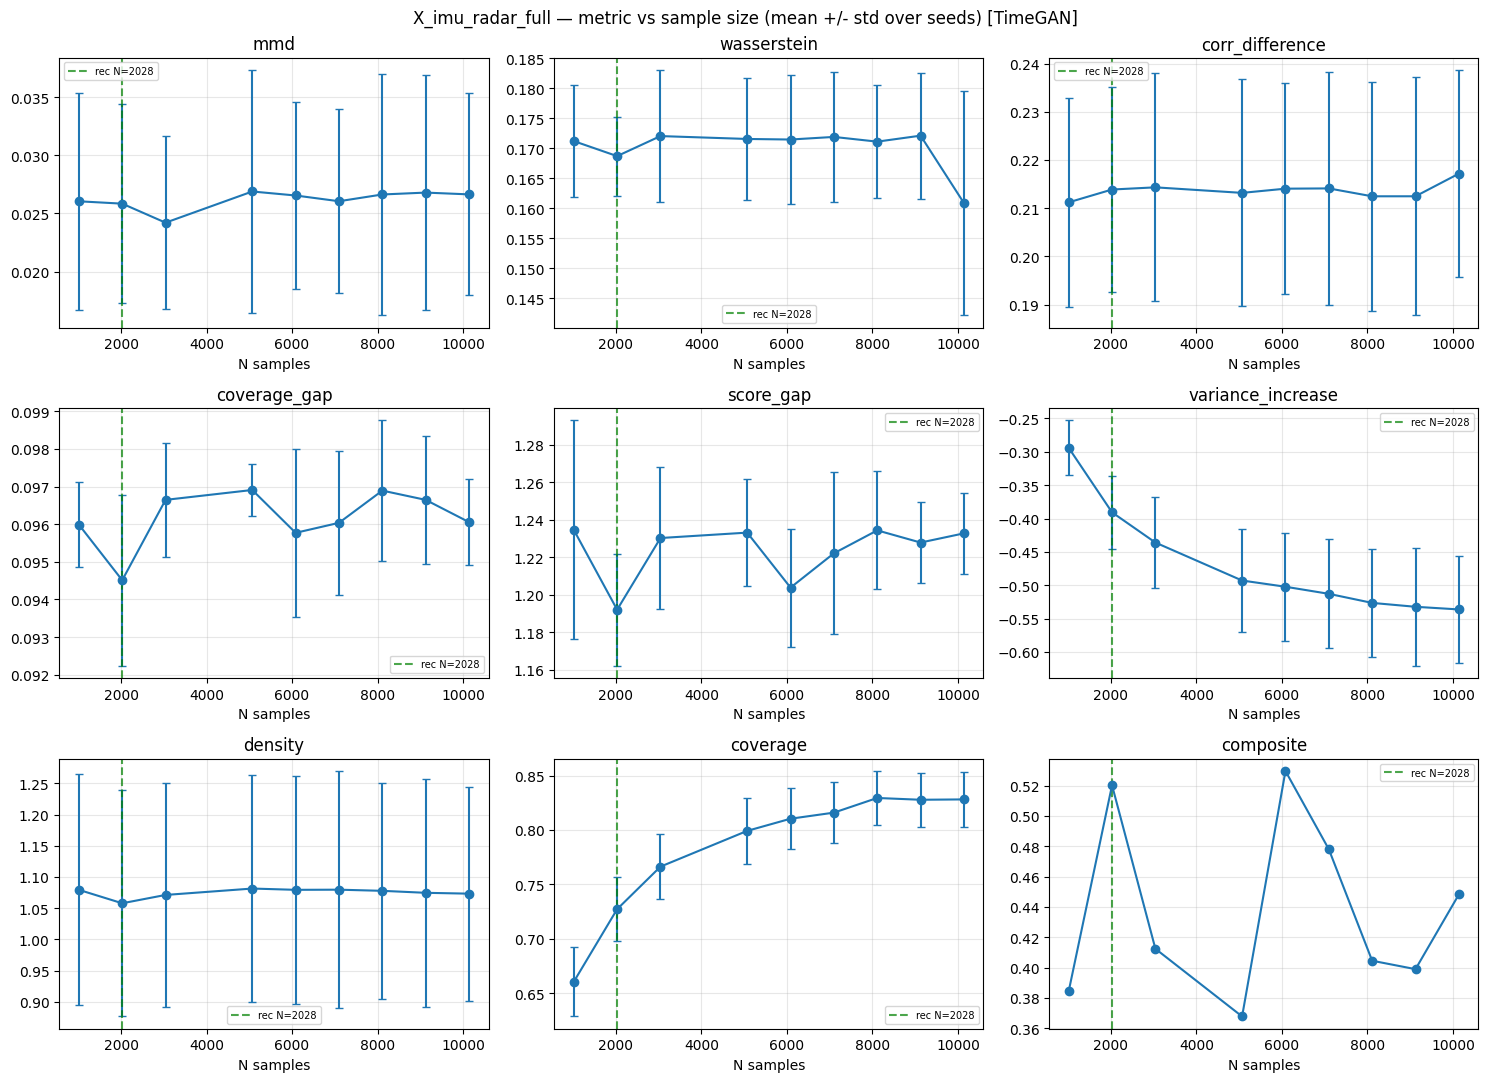

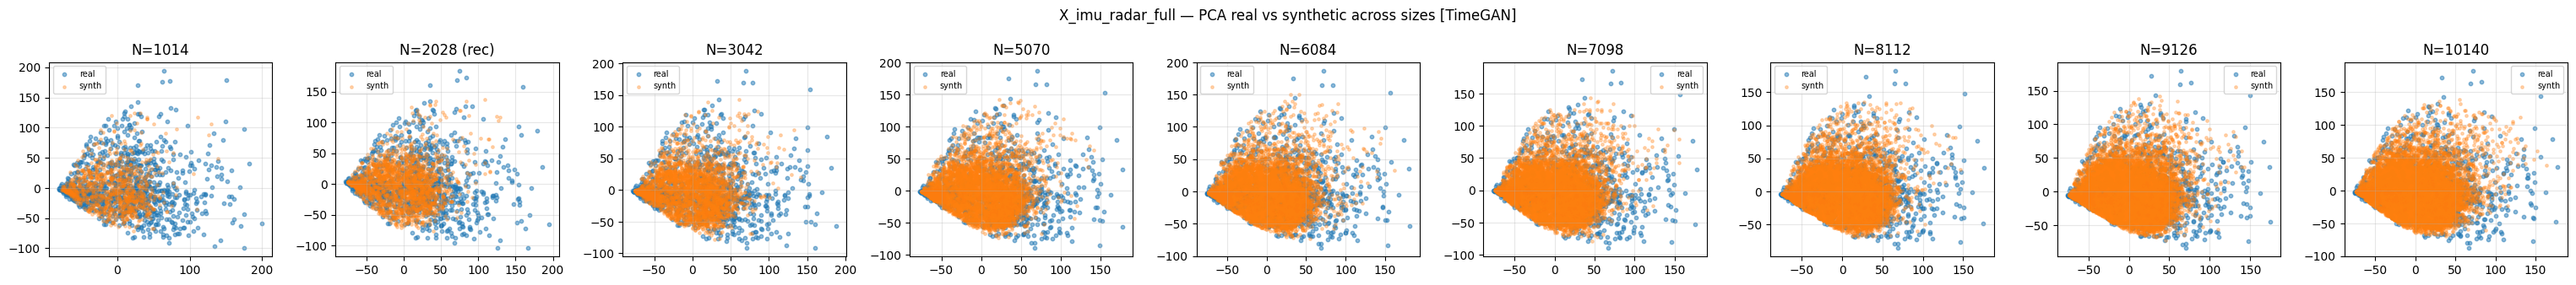

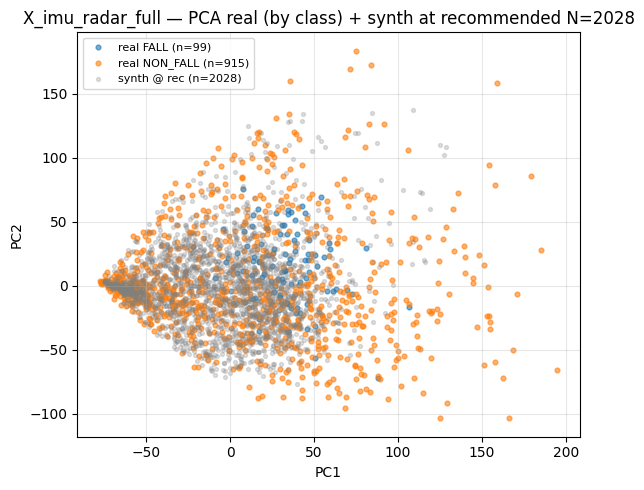

In [15]:
def plot_curves(name):
    sub = AGG[AGG.dataset == name].sort_values("N")
    ss  = AGG_STD[AGG_STD.dataset == name].sort_values("N")
    mets = ["mmd", "wasserstein", "corr_difference", "coverage_gap", "score_gap",
            "variance_increase", "density", "coverage", "composite"]
    recN = REC[name]["N"]
    fig, axes = plt.subplots(3, 3, figsize=(15, 11))
    for ax, mt in zip(axes.ravel(), mets):
        x = sub["N"].values; y = sub[mt].values
        yerr = ss[mt].values if mt in ss and mt != "composite" else None
        ax.errorbar(x, y, yerr=yerr, marker="o", capsize=3)
        ax.axvline(recN, color="green", ls="--", alpha=.7, label=f"rec N={recN}")
        ax.set_title(mt); ax.set_xlabel("N samples"); ax.grid(alpha=.3); ax.legend(fontsize=7)
    fig.suptitle(f"{name} — metric vs sample size (mean +/- std over seeds) [TimeGAN]")
    fig.tight_layout(); fig.savefig(CFG.output_dir / f"{name}_curves.png", dpi=110)
    plt.show(); plt.close(fig)

def plot_pca(name):
    Re = EMB[name]["Re"]; syn = EMB[name]["synth"]; sizes = sorted(syn)
    fig, axes = plt.subplots(1, len(sizes), figsize=(3.4 * len(sizes), 3.4), squeeze=False)
    for j, N in enumerate(sizes):
        allp = np.vstack([Re, syn[N]])
        p = PCA(2, random_state=CFG.seed).fit_transform(allp)
        axes[0][j].scatter(*p[:len(Re)].T, s=10, alpha=.5, label="real")
        axes[0][j].scatter(*p[len(Re):].T, s=6,  alpha=.3, label="synth")
        tag = " (rec)" if N == REC[name]["N"] else ""
        axes[0][j].set_title(f"N={N}{tag}"); axes[0][j].legend(fontsize=7); axes[0][j].grid(alpha=.3)
    fig.suptitle(f"{name} — PCA real vs synthetic across sizes [TimeGAN]")
    fig.tight_layout(); fig.savefig(CFG.output_dir / f"{name}_pca.png", dpi=110)
    plt.show(); plt.close(fig)

def plot_pca_labeled(name):
    if META is None or "label" not in META.columns: return
    Re = EMB[name]["Re"]; syn = EMB[name]["synth"]; recN = REC[name]["N"]
    if recN not in syn: return
    Se = syn[recN]
    allp = np.vstack([Re, Se]); p = PCA(2, random_state=CFG.seed).fit_transform(allp)
    Re_only = p[:len(Re)]; labels = META["label"].values
    fig, ax = plt.subplots(figsize=(6, 5))
    for lab in np.unique(labels):
        m = labels == lab
        ax.scatter(*Re_only[m].T, s=12, alpha=0.6, label=f"real {lab} (n={m.sum()})")
    ax.scatter(*p[len(Re):].T, s=8, alpha=0.25, color="gray", label=f"synth @ rec (n={len(Se)})")
    ax.set_title(f"{name} — PCA real (by class) + synth at recommended N={recN}")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.grid(alpha=.3); ax.legend(fontsize=8)
    fig.tight_layout(); fig.savefig(CFG.output_dir / f"{name}_pca_labeled.png", dpi=110)
    plt.show(); plt.close(fig)

for name in RAW:
    plot_curves(name); plot_pca(name); plot_pca_labeled(name)

## 14. Save synthetic data at the single-pass recommended size + package

This saves the single-pass recommendation. The robust final choice (Section 15+) may pick a different
multiplier and gets its own filenames.

In [16]:
import shutil

for name in RAW:

    models = MODELS[name]

    tgan_fall, prep_fall, _ = models["fall"]
    tgan_nonfall, prep_nonfall, _ = models["nonfall"]

    recN = REC[name]["N"]
    recM = REC[name]["multiplier"]

    set_seeds(CFG.seed)

    synth, synth_labels = generate_class_balanced(
        tgan_fall,
        prep_fall,
        tgan_nonfall,
        prep_nonfall,
        recM,
        CFG
    )

    expected_fall = int(recM * len(RAW_FALL))
    expected_nonfall = int(recM * len(RAW_NONFALL))

    assert len(synth) == recN
    assert int(np.sum(synth_labels == "FALL")) == expected_fall
    assert int(np.sum(synth_labels == "NON_FALL")) == expected_nonfall

    d = CFG.output_dir / name
    d.mkdir(parents=True, exist_ok=True)

    np.save(
        d / "synthetic_recommended.npy",
        synth
    )

    synthetic_meta = pd.DataFrame({
        "sample_id": np.arange(len(synth)),
        "label": synth_labels,
        "generation_type": "TimeGAN",
        "source": "synthetic",
        "multiplier": recM,
        "generation_class": synth_labels,
    })

    synthetic_meta.to_csv(
        d / "metadata_synthetic_recommended.csv",
        index=False
    )

    with open(d / "prep_fall.pkl", "wb") as f:
        pickle.dump(prep_fall, f)

    with open(d / "prep_nonfall.pkl", "wb") as f:
        pickle.dump(prep_nonfall, f)

    tgan_fall.generator.save(d / "generator_fall.keras")
    tgan_fall.supervisor.save(d / "supervisor_fall.keras")
    tgan_fall.recovery.save(d / "recovery_fall.keras")

    tgan_nonfall.generator.save(d / "generator_nonfall.keras")
    tgan_nonfall.supervisor.save(d / "supervisor_nonfall.keras")
    tgan_nonfall.recovery.save(d / "recovery_nonfall.keras")

    pd.DataFrame([{
        "dataset": name,
        "recommended_N": recN,
        "multiplier": recM,
        "synthetic_fall": expected_fall,
        "synthetic_nonfall": expected_nonfall,
        "n_features": prep_fall.F_full,
        "modeled_dim": prep_fall.K
    }]).to_csv(
        d / "metadata.csv",
        index=False
    )

    print(
        f"  {name:20s} saved {synth.shape} "
        f"at recommended N={recN} "
        f"({expected_fall} FALL + {expected_nonfall} NON_FALL)"
    )

arch = shutil.make_archive(
    str(CFG.output_dir),
    "zip",
    root_dir=str(CFG.output_dir)
)

print("\nZipped ->", arch)

    Generating FALL     : 198
    Generating NON_FALL : 1830
  X_imu_radar_full     saved (2028, 32, 1137) at recommended N=2028 (198 FALL + 1830 NON_FALL)

Zipped -> c:\Users\mabideen\Downloads\Data_Augmentation\Stage_2_Data_generation\All_ADL_Generation\timegan_full_dataset.zip


## Reading the results (single pass)

For each dataset the recommended N is the smallest size where fidelity (MMD / Wasserstein / correlation)
has flattened **and** diversity (coverage / variance increase) has stopped growing — i.e. more samples add
`< recommend_tol` composite quality. Beyond it you are paying compute for near-duplicates.

The recommendation above comes from a single sweep. To measure how stable that recommendation is, Section 15
below repeats the entire sweep `N_REPEATS` times and picks a robust final size.

## 15. Repeated-run stability analysis — robust final recommendation

Sections 10–14 produce one recommendation from a single **Generation → Evaluation → Recommendation** pass.
To measure how stable that recommendation is, we now repeat the **entire existing pipeline** `N_REPEATS`
times as independent runs, reusing `run_sweep`, `aggregate` and `recommend` **unchanged** — the existing
evaluation stays the sole authority for each run's recommendation. Each run gets its own seed offset
(`CFG.seed + rep*REP_SEED_STRIDE`), so the runs are independent yet fully reproducible; run 0 keeps the
original `CFG.seed`, so it reproduces the single-pass result and acts as an anchor.

For every dataset we then collect the per-run recommended multiplier, take the **mean** across runs, and
snap that mean to the **nearest multiplier actually generated in the sweep grid** (`CFG.multipliers`).
That snapped multiplier is the robust final representative recommendation. *Example:* runs recommending
`x4, x6, x8, x5, x6` give mean `5.8`, whose nearest available multiplier is `x6`.

The robust final dataset is regenerated at the selected multiplier from the same kept TimeGAN used in
Section 14 (`MODELS[name]`, with `set_seeds(CFG.seed)`), so only the *size* recommendation is made robust
— the generator and methodology are unchanged.

> **Compute note.** TimeGAN training is expensive, and every repetition retrains all `n_seeds` TimeGANs
> for the dataset (one repetition == one full sweep, i.e. roughly the wall-clock time Section 10 already
> took). Total time scales ~linearly with `N_REPEATS`, and the dataset is now 10× larger than the falls-only
> run — **lower `N_REPEATS` below** if you want a quicker pass.

All single-pass outputs are preserved untouched; robust results are written to new filenames
(`*_repeated_final.npy`, `metadata_repeated.csv`, `repeated_run_stability.csv`).

In [17]:
# --- Repeated-run stability configuration (change N_REPEATS to taste) ---
N_REPEATS = 5           # number of independent Generation -> Evaluation -> Recommendation runs
REP_SEED_STRIDE = 1000  # seed spacing between runs (keeps each run's seed block independent)

print(f"Repeated-run analysis: {N_REPEATS} independent runs "
      f"(seeds {CFG.seed} + rep*{REP_SEED_STRIDE}), reusing the existing pipeline unchanged.")

Repeated-run analysis: 5 independent runs (seeds 42 + rep*1000), reusing the existing pipeline unchanged.


In [18]:
# One record per dataset: the recommendation + full evaluation trace from every repetition.
REPEAT_RESULTS = {name: {"seeds": [], "rec_multiplier": [], "rec_N": [],
                         "composite_at_rec": [], "composite_grid": [],
                         "grid_multipliers": None, "grid_N": None,
                         "metric_frames": []} for name in RAW}

for rep in range(N_REPEATS):
    rep_seed = CFG.seed + rep * REP_SEED_STRIDE     # run 0 == CFG.seed -> reproduces the single pass
    cfg_rep = _dc_replace(CFG, seed=rep_seed)       # identical config, independent seed
    set_seeds(rep_seed)                             # keep global RNG state reproducible per run

    # ----- existing pipeline, executed exactly as-is (models are retrained internally) -----
    results_rep, _emb_rep, _models_rep = run_sweep(cfg_rep)      # Generation + Evaluation
    agg_rep, _agg_std_rep = aggregate(results_rep)               # Aggregate over seeds

    for name in RAW:
        sub = agg_rep[agg_rep.dataset == name].sort_values("N").reset_index(drop=True)
        C, recN, recM = recommend(sub, cfg_rep)                  # Recommendation (unchanged authority)
        store = REPEAT_RESULTS[name]
        store["seeds"].append(rep_seed)
        store["rec_multiplier"].append(int(recM))
        store["rec_N"].append(int(recN))
        store["composite_at_rec"].append(float(C[sub["N"].values == recN][0]))
        store["composite_grid"].append(np.asarray(C, float))
        sub_c = sub.copy(); sub_c["composite"] = C; sub_c["rep"] = rep
        store["metric_frames"].append(sub_c)
        if store["grid_multipliers"] is None:
            store["grid_multipliers"] = sub["multiplier"].values.astype(int)
            store["grid_N"] = sub["N"].values.astype(int)

    del _emb_rep, _models_rep     # only recommendations/metrics needed downstream; free memory

    print(f"  rep {rep + 1:>2}/{N_REPEATS} (seed {rep_seed}): "
          + ", ".join(f"{name}->{REPEAT_RESULTS[name]['rec_multiplier'][-1]}x" for name in RAW))

set_seeds(CFG.seed)   # restore the original global seed after the repeated runs
print(f"\nrepeated runs done: {N_REPEATS} x full pipeline over {len(RAW)} dataset(s)")


=== X_imu_radar_full ((1014, 32, 1137)) ===

  -------------------------------
  Seed 42
  -------------------------------
  FALL model: train=79 val=20
  FALL TimeGAN trained in 338s (K=32, dropped=294)
  NON_FALL model: train=732 val=183
  NON_FALL TimeGAN trained in 1328s (K=32, dropped=162)
    Generating FALL     : 99
    Generating NON_FALL : 915
    Generating FALL     : 198
    Generating NON_FALL : 1830
    Generating FALL     : 297
    Generating NON_FALL : 2745
    Generating FALL     : 495
    Generating NON_FALL : 4575
    Generating FALL     : 594
    Generating NON_FALL : 5490
    Generating FALL     : 693
    Generating NON_FALL : 6405
    Generating FALL     : 792
    Generating NON_FALL : 7320
    Generating FALL     : 891
    Generating NON_FALL : 8235
    Generating FALL     : 990
    Generating NON_FALL : 9150

  -------------------------------
  Seed 43
  -------------------------------
  FALL model: train=79 val=20
  FALL TimeGAN trained in 347s (K=32, dropped=2

In [19]:
def _nearest_grid_multiplier(mean_val, grid):
    # nearest multiplier that was actually generated; ties resolve to the smaller (conservative) one
    grid = np.asarray(sorted(set(int(g) for g in grid)))
    return int(grid[int(np.argmin(np.abs(grid - float(mean_val))))])

REPEAT_SUMMARY_ROWS = []
REPEAT_FINAL = {}   # name -> robust final selection

for name in RAW:
    store = REPEAT_RESULTS[name]
    recs = np.asarray(store["rec_multiplier"], float)
    grid_mults = store["grid_multipliers"]; grid_N = store["grid_N"]

    mean_rec = float(recs.mean())                                  # mean recommendation across runs
    sel_mult = _nearest_grid_multiplier(mean_rec, grid_mults)      # snap to nearest generated multiplier
    sel_N = int(grid_N[list(grid_mults).index(sel_mult)])

    # mean composite (existing evaluation score) across runs at the selected multiplier
    comp_grid = np.vstack(store["composite_grid"])                 # (N_REPEATS, n_grid)
    gi = int(list(grid_mults).index(sel_mult))
    mean_comp_at_sel = float(comp_grid[:, gi].mean())

    # mean of the raw evaluation metrics across runs at the selected multiplier
    frames = pd.concat(store["metric_frames"], ignore_index=True)
    sel_metrics = frames[frames["multiplier"] == sel_mult].mean(numeric_only=True)

    REPEAT_FINAL[name] = {
        "mean_multiplier": mean_rec, "selected_multiplier": sel_mult, "selected_N": sel_N,
        "mean_composite_at_selected": mean_comp_at_sel,
        "per_rep_multipliers": [int(m) for m in store["rec_multiplier"]],
        "single_pass_multiplier": int(REC[name]["multiplier"]), "single_pass_N": int(REC[name]["N"]),
    }
    REPEAT_SUMMARY_ROWS.append({
        "dataset": name, "n_repeats": N_REPEATS,
        "per_rep_multipliers": " ".join(f"{m}x" for m in store["rec_multiplier"]),
        "mean_multiplier": round(mean_rec, 3), "selected_multiplier": f"{sel_mult}x",
        "selected_N": sel_N, "single_pass_multiplier": f"{REC[name]['multiplier']}x",
        "mean_composite_at_selected": round(mean_comp_at_sel, 4),
        "mmd":         float(sel_metrics.get("mmd", np.nan)),
        "wasserstein": float(sel_metrics.get("wasserstein", np.nan)),
        "coverage":    float(sel_metrics.get("coverage", np.nan)),
    })

REPEAT_SUMMARY = pd.DataFrame(REPEAT_SUMMARY_ROWS).set_index("dataset")
REPEAT_SUMMARY.to_csv(CFG.output_dir / "repeated_run_stability.csv")

# persist every per-run evaluation table too
per_rep_all = pd.concat([f for name in RAW for f in REPEAT_RESULTS[name]["metric_frames"]],
                        ignore_index=True)
per_rep_all.to_csv(CFG.output_dir / "repeated_run_per_rep_metrics.csv", index=False)

print("################ REPEATED-RUN STABILITY SUMMARY ################")
display(REPEAT_SUMMARY)

################ REPEATED-RUN STABILITY SUMMARY ################


,n_repeats,per_rep_multipliers,mean_multiplier,selected_multiplier,selected_N,single_pass_multiplier,mean_composite_at_selected,mmd,wasserstein,coverage
dataset,,,,,,,,,,
X_imu_radar_full,5,2x 6x 9x 1x 6x,4.8000,5x,5070,2x,0.5766,0.0253,0.1779,0.7969


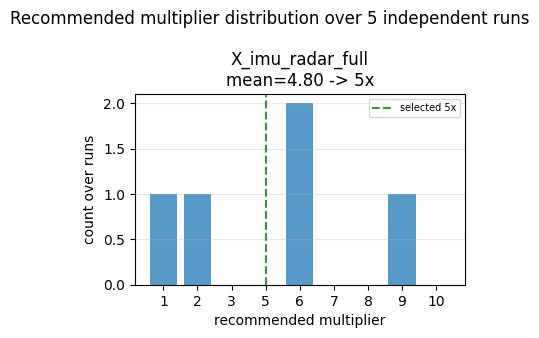

In [20]:
# distribution of the recommended multiplier over the independent runs
grid_all = sorted(set(int(m) for m in CFG.multipliers))
fig, axes = plt.subplots(1, len(RAW), figsize=(4.2 * len(RAW), 3.4), squeeze=False)
for ax, name in zip(axes[0], RAW):
    recs = REPEAT_RESULTS[name]["rec_multiplier"]
    counts = [recs.count(m) for m in grid_all]
    ax.bar([str(m) for m in grid_all], counts, alpha=.75)
    sel = REPEAT_FINAL[name]["selected_multiplier"]
    mean_rec = REPEAT_FINAL[name]["mean_multiplier"]
    ax.axvline(grid_all.index(sel), color="green", ls="--", alpha=.8, label=f"selected {sel}x")
    ax.set_title(f"{name}\nmean={mean_rec:.2f} -> {sel}x")
    ax.set_xlabel("recommended multiplier"); ax.set_ylabel("count over runs")
    ax.grid(alpha=.3, axis="y"); ax.legend(fontsize=7)
fig.suptitle(f"Recommended multiplier distribution over {N_REPEATS} independent runs")
fig.tight_layout(); fig.savefig(CFG.output_dir / "repeated_run_stability.png", dpi=110)
plt.show(); plt.close(fig)

In [21]:
# Regenerate + save the robust final dataset at the selected multiplier.
# FALL and NON_FALL are generated by their respective TimeGAN models.

print(
    "################ FINAL REPRESENTATIVE RECOMMENDATION "
    "(repeated-run) ################\n"
)

for name in RAW:

    fin = REPEAT_FINAL[name]

    sel_N = fin["selected_N"]
    sel_mult = fin["selected_multiplier"]

    models = MODELS[name]

    (
        tgan_fall,
        prep_fall,
        _
    ) = models["fall"]

    (
        tgan_nonfall,
        prep_nonfall,
        _
    ) = models["nonfall"]

    set_seeds(CFG.seed)

    synth, synth_labels = generate_class_balanced(
        tgan_fall,
        prep_fall,
        tgan_nonfall,
        prep_nonfall,
        sel_mult,
        CFG
    )

    # ---------------------------------------------------------
    # Verify expected size and labels
    # ---------------------------------------------------------
    expected_fall = int(sel_mult * len(RAW_FALL))
    expected_nonfall = int(sel_mult * len(RAW_NONFALL))

    assert len(synth) == sel_N

    assert int(np.sum(synth_labels == "FALL")) == expected_fall
    assert int(np.sum(synth_labels == "NON_FALL")) == expected_nonfall

    # ---------------------------------------------------------
    # Save synthetic array
    # ---------------------------------------------------------
    d = CFG.output_dir / name
    d.mkdir(parents=True, exist_ok=True)

    final_path = d / "synthetic_repeated_final.npy"

    np.save(final_path, synth)

    # ---------------------------------------------------------
    # Create SAMPLE-LEVEL synthetic metadata
    # ---------------------------------------------------------
    synthetic_meta = pd.DataFrame({
        "sample_id": np.arange(len(synth)),
        "label": synth_labels,
        "generation_type": "TimeGAN",
        "source": "synthetic",
        "multiplier": sel_mult,
        "generation_class": synth_labels,
    })

    metadata_path = (
        d / "metadata_synthetic_repeated_final.csv"
    )

    synthetic_meta.to_csv(
        metadata_path,
        index=False
    )

    # ---------------------------------------------------------
    # Save preprocessing/model information
    # ---------------------------------------------------------
    with open(
        d / "prep_fall.pkl",
        "wb"
    ) as f:
        pickle.dump(prep_fall, f)

    with open(
        d / "prep_nonfall.pkl",
        "wb"
    ) as f:
        pickle.dump(prep_nonfall, f)

    tgan_fall.generator.save(
        d / "generator_fall.keras"
    )
    tgan_fall.supervisor.save(
        d / "supervisor_fall.keras"
    )
    tgan_fall.recovery.save(
        d / "recovery_fall.keras"
    )

    tgan_nonfall.generator.save(
        d / "generator_nonfall.keras"
    )
    tgan_nonfall.supervisor.save(
        d / "supervisor_nonfall.keras"
    )
    tgan_nonfall.recovery.save(
        d / "recovery_nonfall.keras"
    )

    # ---------------------------------------------------------
    # Experiment-level metadata
    # ---------------------------------------------------------
    pd.DataFrame([{
        "dataset": name,
        "n_repeats": N_REPEATS,
        "per_rep_multipliers": " ".join(
            f"{m}x"
            for m in fin["per_rep_multipliers"]
        ),
        "mean_multiplier": fin["mean_multiplier"],
        "selected_multiplier": sel_mult,
        "selected_N": sel_N,
        "synthetic_fall": expected_fall,
        "synthetic_nonfall": expected_nonfall,
        "mean_composite_at_selected":
            fin["mean_composite_at_selected"],
        "single_pass_multiplier":
            fin["single_pass_multiplier"],
        "single_pass_N":
            fin["single_pass_N"],
        "n_features": prep_fall.F_full,
        "modeled_dim": prep_fall.K,
    }]).to_csv(
        d / "metadata_repeated.csv",
        index=False
    )

    print(f"=== {name} ===")
    print(
        f"  selected multiplier : {sel_mult}x"
    )
    print(
        f"  final dataset       : {tuple(synth.shape)}"
    )
    print(
        f"  FALL                : {expected_fall}"
    )
    print(
        f"  NON_FALL            : {expected_nonfall}"
    )
    print(
        f"  sample metadata     : {metadata_path}"
    )
    print(
        f"  array saved         : {final_path}\n"
    )

################ FINAL REPRESENTATIVE RECOMMENDATION (repeated-run) ################

    Generating FALL     : 495
    Generating NON_FALL : 4575
=== X_imu_radar_full ===
  selected multiplier : 5x
  final dataset       : (5070, 32, 1137)
  FALL                : 495
  NON_FALL            : 4575
  sample metadata     : c:\Users\mabideen\Downloads\Data_Augmentation\Stage_2_Data_generation\All_ADL_Generation\timegan_full_dataset\X_imu_radar_full\metadata_synthetic_repeated_final.csv
  array saved         : c:\Users\mabideen\Downloads\Data_Augmentation\Stage_2_Data_generation\All_ADL_Generation\timegan_full_dataset\X_imu_radar_full\synthetic_repeated_final.npy



## Reading the results (repeated-run)

`repeated_run_stability.csv` shows every per-rep recommendation, the mean, and the snapped-to-grid final
multiplier. If the per-rep multipliers are tight around the mean, the recommendation is stable and the
final `sel_mult` is well-supported; if they scatter across the grid, treat the final choice as one
plausible pick among several and consider raising `N_REPEATS` or `n_seeds` for a tighter estimate.

`synthetic_repeated_final.npy` is the dataset to feed into `QUIDA_Synthetic_PostEvaluation.ipynb` /
`QUIDA_GridSearch_PostEvaluation.ipynb` as the TimeGAN full-dataset entry alongside whatever baseline
you want to compare against. Because the metric columns match the falls-only run and the VAE counterpart
exactly, rows can be concatenated across studies.